In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('country_summary.csv')

In [53]:
df.head()

,country,total_titles,avg_imdb,top_platform,top_genre
0,0,149.0,6.7125,2,1
1,1,294.0,6.7400,2,1
2,2,301.0,6.8500,0,1
3,3,440.0,6.7600,2,1
4,4,220.0,6.8400,2,0


In [4]:
df.isnull().sum()

country         0
total_titles    0
avg_imdb        0
top_platform    0
top_genre       0
dtype: int64

In [5]:
df.columns

Index(['country', 'total_titles', 'avg_imdb', 'top_platform', 'top_genre'], dtype='object')

In [6]:
df.shape

(24, 5)

<Axes: ylabel='total_titles'>

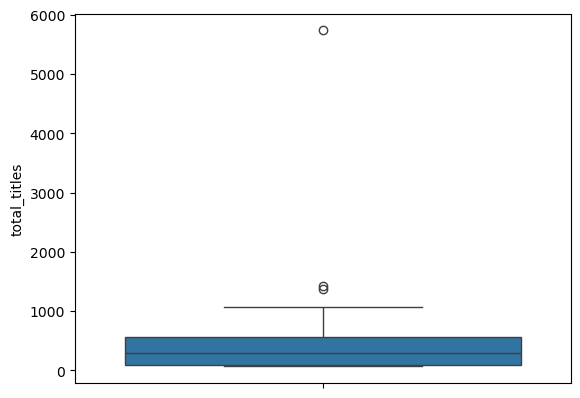

In [7]:
sns.boxplot(df['total_titles'])

In [8]:
q1 = df['total_titles'].describe()['75%']

In [9]:
q3 = df['total_titles'].describe()['25%']

In [10]:
IQR = q1-q3

In [11]:
upper_limit = q1+1.5*IQR

In [12]:
lower_limit = q3-1.5*IQR

In [13]:
df['total_titles'] = df['total_titles'].clip(upper_limit, lower_limit)

<Axes: ylabel='total_titles'>

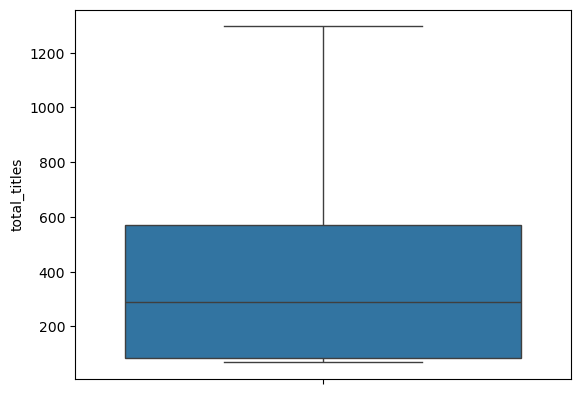

In [14]:
sns.boxplot(df['total_titles'])

<Axes: ylabel='avg_imdb'>

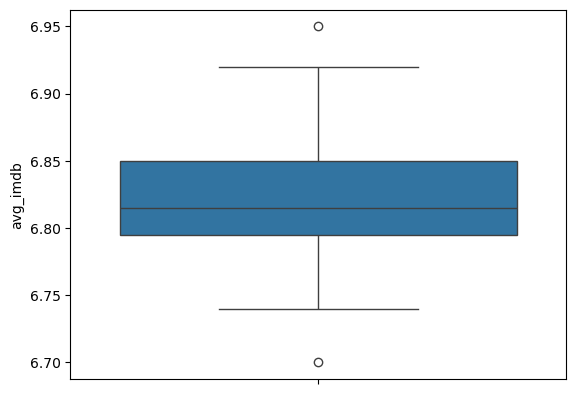

In [15]:
sns.boxplot(df['avg_imdb'])

In [16]:
q1 = df['avg_imdb'].describe()['75%']

In [17]:
q3 = df['avg_imdb'].describe()['25%']

In [18]:
IQR = q1-q3

In [19]:
upper_limit = q1+1.5*IQR

In [20]:
lower_limit = q3-1.5*IQR

In [21]:
df['avg_imdb'] = df['avg_imdb'].clip(upper_limit, lower_limit)

<Axes: ylabel='avg_imdb'>

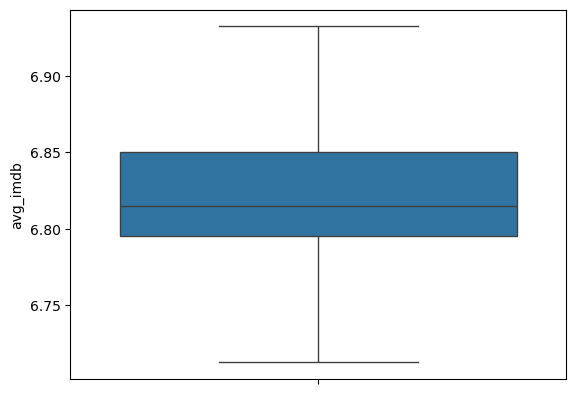

In [22]:
sns.boxplot(df['avg_imdb'])

In [23]:
df.describe()

,total_titles,avg_imdb
count,24.000000,24.000000
mean,431.432292,6.815625
std,424.477700,0.052937
min,69.000000,6.712500
25%,84.250000,6.795000
50%,289.500000,6.815000
75%,569.000000,6.850000
max,1296.125000,6.932500


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [25]:
data = scaler.fit_transform(df[['total_titles', 'avg_imdb']])

In [26]:
df1 = pd.DataFrame(data, columns=['total_titles', 'avg_imdb'])

In [27]:
df1.describe().round()

,total_titles,avg_imdb
count,24.0,24.0
mean,-0.0,0.0
std,1.0,1.0
min,-1.0,-2.0
25%,-1.0,-0.0
50%,-0.0,-0.0
75%,0.0,1.0
max,2.0,2.0


In [28]:
df.dtypes

country          object
total_titles    float64
avg_imdb        float64
top_platform     object
top_genre        object
dtype: object

In [29]:
df['top_platform'].unique

<bound method Series.unique of 0                Netflix
1                Netflix
2     Amazon Prime Video
3                Netflix
4                Netflix
5     Amazon Prime Video
6                Netflix
7                Netflix
8                Netflix
9                Netflix
10               Disney+
11    Amazon Prime Video
12               Netflix
13               Netflix
14               Netflix
15               Netflix
16               Netflix
17               Netflix
18               Netflix
19               Netflix
20               Netflix
21               Netflix
22               Netflix
23               Netflix
Name: top_platform, dtype: object>

In [30]:
df['top_platform'].value_counts()

top_platform
Netflix               20
Amazon Prime Video     3
Disney+                1
Name: count, dtype: int64

In [31]:
df['top_genre'].value_counts()

top_genre
Drama     23
Comedy     1
Name: count, dtype: int64

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['country', 'top_platform', 'top_genre']:
    df[col] = le.fit_transform(df[col])

In [33]:
df.dtypes

country           int64
total_titles    float64
avg_imdb        float64
top_platform      int64
top_genre         int64
dtype: object

In [34]:
X = df.drop(columns=['top_genre'], axis=1)

In [35]:
y = df[['top_genre']]

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [37]:
X_train.shape

(19, 4)

In [38]:
X_test.shape

(5, 4)

In [39]:
y_train.shape

(19, 1)

In [40]:
y_test.shape

(5, 1)

In [41]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()

In [42]:
tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred = tree.predict(X_test)

In [44]:
y_pred

array([1, 1, 1, 1, 1])

In [45]:
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

In [46]:
accuracy_score(y_test,y_pred)

1.0

In [47]:
recall_score(y_test,y_pred)

1.0

In [48]:
confusion_matrix(y_test,y_pred)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


array([[5]])

In [49]:
import pickle

In [50]:
with open('model', 'wb') as file:
    pickle.dump(tree, file)

In [51]:
with open('model', 'rb') as file:
    model = pickle.load(file)

In [52]:
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# 1. Load the saved model
with open('model', 'rb') as file:
    model = pickle.load(file)

st.title("Country Data Predictor")
st.write("Enter the details below to get a prediction.")

# 2. Create input fields based on your dataset columns
# Example: If you have a column 'feature_1'
feature_1 = st.number_input("Enter Feature 1 Value", value=0.0)
feature_2 = st.selectbox("Select Category", options=[0, 1, 2])

# 3. Prediction logic
if st.button("Predict"):
    # Create a dataframe or array for the input
    input_data = np.array([[feature_1, feature_2]])
    prediction = model.predict(input_data)
    
    st.success(f"The predicted result is: {prediction[0]}")

2026-04-24 10:23:51.322 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.230 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-24 10:23:53.232 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.234 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.240 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-24 10:23:53.244 Thread 'MainThread': mi